## Environment Setup
We set `CUDA_LAUNCH_BLOCKING=1` to make CUDA operations synchronous. This forces GPU errors to surface at the exact line they occur rather than being reported later critical for debugging.

## Memory Fragmentation Fix
PyTorch's CUDA allocator can fragment GPU memory over long training runs. Setting `expandable_segments:True` allows the allocator to grow segments dynamically, reducing out-of-memory errors on long training sessions.

## GPU Cache Clear
Before we begin, we explicitly free any leftover tensors from previous runs. `gc.collect()` removes Python objects and `torch.cuda.empty_cache()` releases the GPU memory back to the OS allocator.


In [1]:
import os
import torch
import gc
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Enable memory optimization for fragmentation
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# Clear old tensors from memory before starting
gc.collect()
torch.cuda.empty_cache()

## Imports
We import PyTorch for the model, HuggingFace `datasets` and `transformers` for data loading and the pretrained baseline, and `MarianMTModel` which is the Helsinki-NLP family of translation models we'll compare against our custom seq2seq.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

#And for the pretrained model from huggingface
from transformers import MarianMTModel, MarianTokenizer
from nltk import sent_tokenize
import torch

#for ploting
import matplotlib.pyplot as plt

#for timing
import time

## Tokenizer Setup
We reuse GPT-2's BPE tokenizer for both English and French. Since GPT-2 has no padding token by default, we add `[PAD]` manually. We extract the `BOS` (beginning-of-sequence) token ID which will be used to kick off the decoder during inference.

In [3]:
#tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.add_special_tokens({'pad_token': '[PAD]'})

#simple test 
text_en = "the tokenization is very important in NLP"
token_id = tokenizer(text_en)["input_ids"]
print(f"the token ids:", token_id)

print("\nBos token:", tokenizer.bos_token)
print("Bos token ID:", tokenizer.bos_token_id)
print("Special tokens map:", tokenizer.special_tokens_map)

PAD_ID = tokenizer.pad_token_id 
BOS_ID = tokenizer.bos_token_id

print("Your official Padding ID is:", PAD_ID)  # This will naturally be 50257
print("Your official BOS ID is:", BOS_ID)      # This will naturally be 50256

the token ids: [1169, 11241, 1634, 318, 845, 1593, 287, 399, 19930]

Bos token: <|endoftext|>
Bos token ID: 50256
Special tokens map: {'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '[PAD]'}
Your official Padding ID is: 50257
Your official BOS ID is: 50256


## Encoder
The encoder embeds each source token into a dense vector, then processes the full sequence through an LSTM. The final hidden state `(h_n, c_n)` is a compressed representation of the entire input this becomes the "context vector" passed to the decoder.

In [4]:
#embedding_dim=256, hidden_stat_dim=512, input_dim=VOCAB_SIZE
class Encoder(nn.Module):
    def __init__(self, embedding_dim, hidden_stat_dim, input_dim):
        super().__init__()
        # input_dim = total size of vocabulary
        # embading_dim = size of the dense word vectors
        self.embading = nn.Embedding(input_dim,embedding_dim= embedding_dim, padding_idx=tokenizer.pad_token_id)
        # The LSTM's input_size must match the embedding_dim
        self.lstm = nn.LSTM(input_size= embedding_dim, hidden_size= hidden_stat_dim,batch_first=True)

    def forward(self, input):
        # input shape: (batch_size, sequence_length)
        embading_input = self.embading(input)
        # embading_input shape: (batch_size, sequence_length, embading_dim)
        
        # LSTM processes the entire sequence
        output , hidden = self.lstm(embading_input)
        # 'hidden' is a tuple: (h_n, c_n)
        # h_n shape: (1, batch_size, hiden_stat_dim)
        # c_n shape: (1, batch_size, hiden_stat_dim)
        return hidden 


## Decoder
The decoder generates one token at a time. At each step it receives the previous token and the previous hidden state, and outputs a distribution over the vocabulary via a linear layer. During training, teacher forcing can replace the predicted token with the ground-truth token to speed up convergence.

In [5]:
#Now the decoder parte 
class Decoder(nn.Module):
    def __init__(self,output_dim, embedding_dim, hidden_stat_dim):#output_dim, emb_dim, hidden_dim
        super().__init__()
        self.embading = nn.Embedding(output_dim, embedding_dim= embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_stat_dim, batch_first=True)
        self.linear = nn.Linear(hidden_stat_dim, output_dim)
       

    def forward(self, input_token, previous_hidden):
        # input_token shape: (batch_size) -> unsqueeze to (batch_size, 1) for seq_len=1
        input_token = input_token.unsqueeze(1)
        # embedded shape: (batch_size, 1, embading_dim)
        embading = self.embading(input_token)
        output, hidden_state = self.lstm(embading, previous_hidden)
       
        # output shape: (batch_size, 1, hidden_stat_dim)
        # Squeeze sequence dimension out before sending to Linear layer
        prediction = self.linear(output.squeeze(1))
        # prediction shape: (batch_size, output_dim) -> Raw continuous logits
        
        return prediction, hidden_state  


## Seq2Seq Model  Putting It Together
The `Seq2Seq` class wires the encoder and decoder. It encodes the full source sequence, then runs the decoder in a loop up to `max_length` steps. Teacher forcing is applied at a configurable ratio 50% during training means half the time the decoder sees the true previous token, and half the time it sees its own prediction.

* Seq2Seq Model with Teacher Forcing
* Batch size & vocab size: extracted from input and decoder.
* Encoding: input sequence → encoder → context vector (hidden).
* Start token: initialize decoder with token 0.

* Loop over max_len:
* Decoder predicts next token.


* top1 → token with max probability.
* Append top1 to outputs.
* Teacher forcing: sometimes feed true target token instead of prediction.
* Return predictions: concatenated sequence of token IDs.


In [6]:


class Seq2Seqmodel(nn.Module):
    def __init__(self, encoder,decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, source, targ = None, teacher_forcing_ratio=0.5):
        # source shape: (batch_size, source_seq_len)
        # target shape: (batch_size, target_seq_len)
        batch_size = source.shape[0]

        max_length = targ.shape[1] if targ is not None else 20
        vocab_size = self.decoder.linear.out_features

        # We must collect the continuous logits tensor to calculate loss later
        outputs = torch.zeros(max_length, batch_size, vocab_size).to(self.device) 

        # Get initial context tuple (h_n, c_n) from encoder
        hidden= self.encoder(source)#context_vector = hidden
        # FIXED: Use the exact dynamic BOS token ID filled with the correct type
        input_token = torch.full((batch_size,), BOS_ID, dtype=torch.long).to(self.device)

        for i in range(max_length):
            prediction, hidden_state  = self.decoder(input_token, hidden)
            # Store continuous predictions: shape (batch_size, vocab_size) at time t
            outputs[i] = prediction

            #the next hidden state is the predicted one
            hidden = hidden_state
            
            top_token = prediction.argmax(1)
            

            if targ is not None and torch.rand(1).item()<teacher_forcing_ratio : #so like that i have a 50% force teaching
                input_token = targ[:,i]# Feed actual ground truth token
            else: 
                input_token = top_token # Feed model's own guess

        #the output format is (max_length, batch_size, vocab_size)    
        
        # Permute outputs to return a standard shape: (batch_size, max_length, vocab_size)
        return outputs.permute(1, 0, 2)


## Dataset Loading
We use the OPUS-100 dataset (Helsinki-NLP), a massively multilingual parallel corpus. We limit training to 150,000 English-French pairs so the training will not take too much time, since we are using limited hardware resources from Kaggle, while keeping the full 2,000-example validation and test splits.
150,000 pairs is still sufficient to demonstrate the model's ability to learn translation patterns, and the validation/test splits remain untouched to ensure evaluation integrity.

In [7]:

#the "en-fr", "en-ar" refare to engish to arbic , to french
dataset_f = load_dataset("Helsinki-NLP/opus-100", "en-fr")
"""dataset_a = load_dataset("Helsinki-NLP/opus-100", "ar-en")"""

#now let's get the train, validation and test
#for french
#the original data contine 1M exemple but since i' have a poor Hard were i will go only with 150k
train_data_f = dataset_f["train"].select(range(150_000)) 

print(f"Total training pairs for engish to french: {len(train_data_f)}")

Total training pairs for engish to french: 150000


In [8]:
#Now let's see a single exempel for both arabic and french
# OPUS-100 store data insid a translation column
entfr_pair = train_data_f[27]["translation"]
print("\n--- Exemple of raw traine en-fr dataset ---")
print(entfr_pair)

"""print("\n--- Exemple of raw traine ar-en dataset ---")
arten_pair = train_data_a[21]["translation"]
print(arten_pair)"""


--- Exemple of raw traine en-fr dataset ---
{'en': "'Intérêt public' would mean that the State could make use in some way of a potestative clause to release itself quite unilaterally from the obligations of the Directive.", 'fr': "«Intérêt public» équivaudrait, de la part de l'État, à se prévaloir, en quelque sorte, d'une clause potestative de la possibilité de s'affranchir de façon tout à fait unilatérale des obligations de la directive."}


'print("\n--- Exemple of raw traine ar-en dataset ---")\narten_pair = train_data_a[21]["translation"]\nprint(arten_pair)'

## Tokenization & Filtering
Before tokenizing, we filter out: structurally broken rows, empty strings, sentences over 1,000 characters (to avoid extreme outliers), and identical source/target pairs (copy artifacts in the dataset). We then tokenize with a max length of 64 tokens per sequence.

In [9]:
#the tokenization function
def clean_and_tokenize_f(examples):
    keep_en = []
    keep_fr = []
    
    for ex in examples["translation"]:
        # 1. Base Structural Check (Essential to prevent Python None type crashes)
        if not ex or "en" not in ex or "fr" not in ex:
            continue
            
        en_str = str(ex["en"]).strip()
        fr_str = str(ex["fr"]).strip()
        
        # 2. Skip completely empty strings
        if len(en_str) == 0 or len(fr_str) == 0:
            continue
            
        # 3. Filter by character/word estimation instead of forcing truncation.
        # If a row is absurdly long, we drop the whole row to keep sentences intact.
        # 1000 characters is roughly 200-250 words.
        if len(en_str) > 1000 or len(fr_str) > 1000:
            continue
            
        if ex["en"]==ex["fr"]:#why is this, the exemple train_data_f[0]["translation"] the "en","ar" are the same
            continue
        keep_en.append(en_str)
        keep_fr.append(fr_str)
        
    # Now we tokenize WITHOUT truncation. 
    # The sequences keep their exact natural lengths.
    return{"en_ids": tokenizer(keep_en, add_special_tokens=True, truncation=True, max_length=64)["input_ids"],
           "fr_ids": tokenizer(keep_fr, add_special_tokens=True, truncation=True, max_length=64)["input_ids"] }




## Applying Tokenization
We apply the tokenization function across the full dataset in batches of 1,000. The original `translation` column is removed and replaced with `en_ids` and `fr_ids`. The dataset is then cast to PyTorch tensor format for direct use in a `DataLoader`.

In [10]:
#now we will map every think together
print("Tokenizing French-English dataset...")
tokenized_f = train_data_f.map(
    clean_and_tokenize_f,
    batched = True,
    batch_size =1000,
    remove_columns = ["translation"]
    
)
# Force the dataset to format directly into PyTorch tensors
tokenized_f.set_format(type="torch", columns=["en_ids", "fr_ids"])


Tokenizing French-English dataset...


## Collate / Padding Function
Since sequences in a batch have different lengths, we pad them to the longest sequence in that batch using `pad_sequence`. The `PAD_ID` token is used as the fill value, and the loss function will later be told to ignore this index.



In [11]:
#Padding sequence pear batch 
def padding_function(batch):
    #batch [{"en_ids":[], "fr":[]},...]
    #let'e make the batch as tensor
    en_batch = [item["en_ids"] for item in batch]
    fr_batch = [item["fr_ids"] for item in batch]

    #define the pad token
    PAD_ID = tokenizer.pad_token_id

    #padding the sequence now 
    en_padded = torch.nn.utils.rnn.pad_sequence(en_batch, batch_first=True, padding_value= PAD_ID)
    fr_padded = torch.nn.utils.rnn.pad_sequence(fr_batch, batch_first=True, padding_value= PAD_ID)
    
    return {
        "en": en_padded,
        "fr": fr_padded
    }

## DataLoader
We wrap the tokenized dataset in a PyTorch `DataLoader` with a batch size of 8 and shuffle enabled. The custom `padding_function` is passed as `collate_fn` to handle variable-length sequences within each batch.

In [12]:
#now the data loader
train_loader_f = DataLoader(
    dataset = tokenized_f,
    batch_size=8,
    shuffle=True,
    num_workers = 2,
    pin_memory=True,
    collate_fn=padding_function
)


## Model Instantiation & Hyperparameters
We instantiate the encoder and decoder with 256-dimensional embeddings and 512-dimensional hidden states, then wrap them in the `Seq2Seq` model. Adam is used as the optimizer with a learning rate of 0.001, and `CrossEntropyLoss` is configured to ignore the padding token index.

In [13]:
# Hyperparameter Setup 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VOCAB_SIZE = len(tokenizer)

encoder = Encoder(embedding_dim=256, hidden_stat_dim=512, input_dim=VOCAB_SIZE)
decoder = Decoder(output_dim=VOCAB_SIZE, embedding_dim=256, hidden_stat_dim=512)
model_f = Seq2Seqmodel(encoder, decoder, device).to(device)
#model_a = Seq2Seqmodel(encoder, decoder, device).to(device)

optimizer = optim.Adam(model_f.parameters(), lr=0.001)

# the loss function should ignore index 19999 (the padding index) 
# so the padded don't ruin your gradients!
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

## Training Loop with Mixed Precision & Gradient Accumulation
Training uses two key techniques for efficiency on limited hardware:
- **Mixed precision (`autocast`)**: computes in FP16 where safe, saving GPU memory.
- **Gradient accumulation**: gradients are summed over 8 mini-batches before a weight update, giving an effective batch size of 64 without requiring it to fit in memory at once.

Gradients are clipped at norm 1.0 to prevent exploding gradients, a common issue in RNNs.

In [14]:
# Initialize the GradScaler for mixed precision
scaler = torch.amp.GradScaler('cuda')

epochs = 3
Loss = []
accumulation_steps = 8  # Accumulate gradients over 8 batches (Effective batch size = 8 * 8 = 64)

start_time = time.time()
for epoch in range(epochs):
    model_f.train()
    epoch_loss = 0
    
    # Clear gradients at the very start of the epoch
    optimizer.zero_grad()
    
    for batch_idx, batch in enumerate(train_loader_f):
        src = batch["en"].to(device)   # English (Input)
        trg = batch["fr"].to(device)   # French (Target)
        
        # 1. Forward pass under mixed precision autocast
        with torch.amp.autocast(device_type='cuda'):
            output = model_f(src, trg, teacher_forcing_ratio=0.5)
            
            output_dim = output.shape[-1]
            output_flattened = output.reshape(-1, output_dim)
            trg_flattened = trg.reshape(-1)
            
            # CRITICAL: Divide the loss by accumulation steps so gradients are averaged correctly
            loss = criterion(output_flattened, trg_flattened) / accumulation_steps
            
        # 2. Backward pass (scales the loss and computes gradients)
        scaler.scale(loss).backward()
        
        # Track the un-divided loss value for logging
        epoch_loss += loss.item() * accumulation_steps
        
        # 3. Only update weights after accumulating gradients for 'accumulation_steps' batches
        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader_f):
            
            # Unscale gradients before clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_f.parameters(), max_norm=1.0)
            
            # Step the optimizer and update the scaler
            scaler.step(optimizer)
            scaler.update()
            
            # Reset gradients for the next window of accumulated batches
            optimizer.zero_grad()
            
        if batch_idx % 100 == 0:
            # Display true loss value
            print(f"Epoch [{epoch+1}/{epochs}] | Batch {batch_idx} | Loss: {(loss.item() * accumulation_steps):.4f}")
            
    avg_epoch_loss = epoch_loss / len(train_loader_f)
    Loss.append(avg_epoch_loss)        
    print(f"==> Epoch {epoch+1} Complete. Average Loss: {avg_epoch_loss:.4f}")

end_time =  time.time()
timing = end_time - start_time

print(f"The training took {timing/3600:.2f} hours ({timing/60:.4f} minutes)")
    

Epoch [1/3] | Batch 0 | Loss: 10.8359
Epoch [1/3] | Batch 100 | Loss: 6.8177
Epoch [1/3] | Batch 200 | Loss: 6.3198
Epoch [1/3] | Batch 300 | Loss: 6.8005
Epoch [1/3] | Batch 400 | Loss: 6.7779
Epoch [1/3] | Batch 500 | Loss: 7.2558
Epoch [1/3] | Batch 600 | Loss: 6.4401
Epoch [1/3] | Batch 700 | Loss: 6.3845
Epoch [1/3] | Batch 800 | Loss: 6.4079
Epoch [1/3] | Batch 900 | Loss: 6.5688
Epoch [1/3] | Batch 1000 | Loss: 6.3390
Epoch [1/3] | Batch 1100 | Loss: 6.7516
Epoch [1/3] | Batch 1200 | Loss: 6.5239
Epoch [1/3] | Batch 1300 | Loss: 6.3813
Epoch [1/3] | Batch 1400 | Loss: 6.5735
Epoch [1/3] | Batch 1500 | Loss: 6.4612
Epoch [1/3] | Batch 1600 | Loss: 6.3461
Epoch [1/3] | Batch 1700 | Loss: 6.1730
Epoch [1/3] | Batch 1800 | Loss: 6.6893
Epoch [1/3] | Batch 1900 | Loss: 6.9960
Epoch [1/3] | Batch 2000 | Loss: 5.9182
Epoch [1/3] | Batch 2100 | Loss: 6.1146
Epoch [1/3] | Batch 2200 | Loss: 6.1191
Epoch [1/3] | Batch 2300 | Loss: 5.9046
Epoch [1/3] | Batch 2400 | Loss: 6.2436
Epoch [1/3]

## Test Set Preparation
We load 2,000 examples from the test split, apply the same tokenization pipeline used during training, and wrap them in a `DataLoader`. Note: `shuffle=True` on a test set is unnecessary but harmless.

In [15]:
#now the data processing for test 
test_data_f = dataset_f["test"].select(range(2000))

#map the clean and tokenize the test data
#now we will map every think together
print("Tokenizing French-English dataset...")
test_tokenized_f = test_data_f.map(
    clean_and_tokenize_f,
    batched = True,
    batch_size =1000,
    remove_columns = ["translation"]
) 

test_tokenized_f.set_format(type="torch", columns=["en_ids", "fr_ids"])

#now the data loader
test_loader_f = DataLoader(
    dataset = test_tokenized_f,
    batch_size=8,
    shuffle=True,
    num_workers = 4,
    collate_fn=padding_function
)
    


Tokenizing French-English dataset...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## Evaluation
We switch the model to `eval()` mode and disable gradient computation with `torch.no_grad()`. Teacher forcing is set to `0.0` so the model relies entirely on its own predictions  a realistic inference scenario. We compute and average the cross-entropy loss across all test batches.

In [22]:
model_f.eval()
total_loss = 0.0
total_samples = 0
batch_test_losses = []  

with torch.no_grad():
    for batch_id, batch in enumerate(test_loader_f):
        src  = batch["en"].to(device)
        targ = batch["fr"].to(device)

        # Pass targ=None so the decoder runs freely (no ground-truth length leakage)
        output = model_f(src, targ=None, teacher_forcing_ratio=0.0)

        # Align sequence lengths
        min_len = min(output.shape[1], targ.shape[1])
        output  = output[:, :min_len, :]
        targ    = targ[:,   :min_len]

        # Flatten for CrossEntropyLoss
        output_dim     = output.shape[-1]
        output_flatten = output.reshape(-1, output_dim)
        targ_flatten   = targ.reshape(-1)

        loss = criterion(output_flatten, targ_flatten)

        # Accumulate weighted by real batch size
        batch_size     = src.shape[0]
        total_loss    += loss.item() * batch_size
        total_samples += batch_size

        # Log every 100 batches like the training loop
        if batch_id % 100 == 0:
            print(f"Batch {batch_id} | Test Loss: {loss.item():.4f}")
            batch_test_losses.append(loss.item())

# Normalize to match the length of training Loss list
step = max(1, len(batch_test_losses) // len(Loss))
batch_test_losses_normalized = batch_test_losses[::step][:len(Loss)]

avg_test_loss = total_loss / total_samples
print(f"Average Test Loss: {avg_test_loss:.4f}")

Batch 0 | Test Loss: 6.4015
Batch 100 | Test Loss: 6.9429
Batch 200 | Test Loss: 5.9754
Average Test Loss: 6.3361


## Loss Visualization
We plot the training and test loss curves across epochs to diagnose underfitting/overfitting.


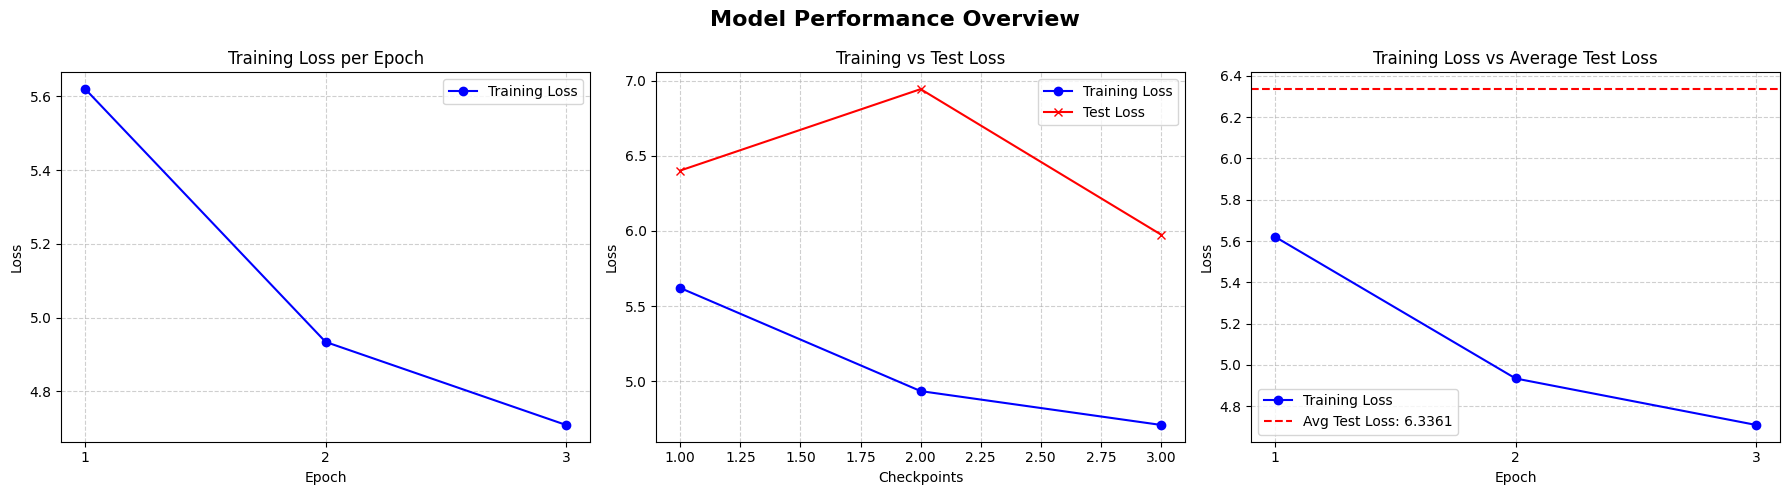

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Overview', fontsize=16, fontweight='bold')


axes[0].plot(range(1, epochs + 1), Loss, color='blue', marker='o', label='Training Loss')
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(range(1, epochs + 1))
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()


axes[1].plot(range(1, len(Loss) + 1), Loss, color='blue', marker='o', label='Training Loss')
axes[1].plot(range(1, len(batch_test_losses_normalized) + 1), batch_test_losses_normalized, color='red', marker='x', label='Test Loss')
axes[1].set_title('Training vs Test Loss')
axes[1].set_xlabel('Checkpoints')
axes[1].set_ylabel('Loss')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()


axes[2].plot(range(1, epochs + 1), Loss, color='blue', marker='o', label='Training Loss')
axes[2].axhline(y=avg_test_loss, color='red', linestyle='--', label=f'Avg Test Loss: {avg_test_loss:.4f}')
axes[2].set_title('Training Loss vs Average Test Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_xticks(range(1, epochs + 1))
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

## Results Analysis

The plots reveal a clear gap between the training loss (~4.7) and the average 
test loss (~6.3), which may initially look like overfitting. However, the real 
cause is the significant data reduction we applied before training.

The original OPUS-100 dataset contains **1,000,000** English-French sentence pairs.
Due to limited hardware resources from Kaggle, we trained on only **150,000** pairs 
 just 15% of the full dataset (and it take over 6h of training). This means the model was exposed to a very limited 
vocabulary and a narrow range of sentence structures, so when it encounters the 
wider variety of expressions in the test set, it struggles to generalize.

### What this tells us:
- The model **is learning**  the training loss drops consistently across all 3 epochs
- The model **is not overfitting**  it hasn't memorized the training data, it simply 
  hasn't seen enough of it
- This is a classic case of **underfitting due to data scarcity**

### What would improve the results:
- Training on the full **1,000,000** pairs
- Training for more than **3 epochs**
- Using a larger hidden state dimension (currently 512)


## Saving the Model
We save only the model weights (`state_dict`) rather than the full model object, which is the recommended PyTorch practice. This allows the architecture to be redefined independently from the learned parameters.

In [24]:
# Save the weights of your models
torch.save(model_f.state_dict(), "seq2seq_french_model1.pt")
print("Models successfully saved to disk!")

Models successfully saved to disk!


## Pretrained Baseline Helsinki-NLP MarianMT
As a second approach, we load a production-grade translation model directly from HuggingFace (`opus-mt-en-fr`). To handle texts longer than the model's 512-token limit, we first split the input into sentences using NLTK's `sent_tokenize`, translate each sentence independently, and then join the results.

In [25]:
def translate_large_text(text,model_name="Helsinki-NLP/opus-mt-en-fr"):
    #now we loading the tokenizer and the model
    tokenizer = MarianTokenizer.from_pretrained(model_name)
    model = MarianMTModel.from_pretrained(model_name)

    #Now let's break the large text to sentence
    sentences = sent_tokenize(text)

    #translat text 
    translated_texts = []
    for sentence in sentences:
        if not sentence.strip():
            continue

        input_sentence = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True)

        with torch.no_grad():
            translate_sentence = model.generate(**input_sentence)

        translate_sentence = tokenizer.decode(translate_sentence[0], skip_special_tokens = True)
        translated_texts.append(translate_sentence)

    return " ".join(translated_texts)  

## Custom Model vs. Pretrained Model  Side-by-Side Comparison
Here we run both the pretrained MarianMT model and our custom seq2seq LSTM on the same English input to qualitatively compare their outputs. This demonstrates the gap between a production NMT system and a from-scratch implementation and shows both approaches.



In [26]:
#the pretrained one
large_text = """
            Artificial intelligence is changing the world rapidly. Machine translation allows people 
            from different cultures to communicate effortlessly. However, long documents pose a challenge 
            for small translation models due to strict token length limitations. By splitting the text into 
            individual sentences, we can process indefinitely large files without cutting off any information.
            """
french_translation =translate_large_text(text= large_text, model_name="Helsinki-NLP/opus-mt-en-fr") 
print("---------THE French Translation Pretrained one---------")
print(french_translation)


#the custom one
# tokenize the text
input_ids = tokenizer(large_text, return_tensors="pt", truncation=True, max_length=64)["input_ids"].to(device)

# Run the model in eval mode
model_f.eval()
with torch.no_grad():
    output = model_f(input_ids, targ=None, teacher_forcing_ratio=0.0)

predicted_ids = output.argmax(-1).squeeze(0)  

# Decode the predicted token IDs back to text
french_translation = tokenizer.decode(predicted_ids, skip_special_tokens=True)

print("\n\n--------- Custom Model Translation ---------")
print(french_translation)

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


---------THE French Translation Pretrained one---------
L'intelligence artificielle change rapidement le monde. La traduction automatique permet aux personnes de différentes cultures de communiquer sans effort. Cependant, les documents longs posent un défi pour les petits modèles de traduction en raison de limites strictes de longueur des jetons. En divisant le texte en phrases individuelles, nous pouvons traiter des fichiers indéfiniment importants sans couper aucune information.


--------- Custom Model Translation ---------
Rapport de l'éé de de la de la de la de la de la de
